## Load Data

In [26]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../dataset/dataset_merged.csv')
df.head()

,tanggal,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,Cabai Merah Besar
0,2024-05-01,21.8,30.0,26.1,81.0,2.5,5.2,2.0,240.0,83350.000000
1,2024-05-02,21.8,32.2,26.1,73.0,5.0,6.0,2.0,120.0,84150.000000
2,2024-05-03,22.0,32.0,26.2,73.0,3.9,5.3,2.0,80.0,82500.000000
3,2024-05-04,21.4,31.6,25.1,76.0,2.8,6.7,3.0,120.0,85416.666667
4,2024-05-05,21.2,31.2,25.5,72.0,1.7,6.4,5.0,220.0,88333.333333


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tanggal            727 non-null    object 
 1   TN                 727 non-null    float64
 2   TX                 727 non-null    float64
 3   TAVG               727 non-null    float64
 4   RH_AVG             727 non-null    float64
 5   RR                 727 non-null    float64
 6   SS                 727 non-null    float64
 7   FF_X               727 non-null    float64
 8   DDD_X              727 non-null    float64
 9   Cabai Merah Besar  727 non-null    float64
dtypes: float64(9), object(1)
memory usage: 56.9+ KB


## Set Data Types

In [28]:
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 727 entries, 0 to 726
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   tanggal            727 non-null    datetime64[ns]
 1   TN                 727 non-null    float64       
 2   TX                 727 non-null    float64       
 3   TAVG               727 non-null    float64       
 4   RH_AVG             727 non-null    float64       
 5   RR                 727 non-null    float64       
 6   SS                 727 non-null    float64       
 7   FF_X               727 non-null    float64       
 8   DDD_X              727 non-null    float64       
 9   Cabai Merah Besar  727 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 56.9 KB


In [29]:
df_features = df.copy()
df_features.rename(columns={'Cabai Merah Besar': 'Harga'}, inplace=True)

## Feature Engineering

In [30]:
# Lag Curah Hujan (RR) dan Kelembapan (RH_AVG) 30 & 45 hari lalu
df_features['RR_lag_30'] = df_features['RR'].shift(30)
df_features['RR_lag_45'] = df_features['RR'].shift(45)

df_features['RH_lag_30'] = df_features['RH_AVG'].shift(30)
df_features['RH_lag_45'] = df_features['RH_AVG'].shift(45)

# B. Membuat Fitur Rolling (Rata-rata akumulasi cuaca 14 hari terakhir)
df_features['RR_rolling_mean_14'] = df_features['RR'].rolling(window=14).mean()
df_features['RH_rolling_mean_14'] = df_features['RH_AVG'].rolling(window=14).mean()

# C. Fitur Historis Harga Target (Pemicu akurasi utama runtun waktu)
df_features['Cabai_lag_1'] = df_features['Harga'].shift(1)  # Harga cabai kemarin
df_features['Cabai_lag_7'] = df_features['Harga'].shift(7)  # Harga cabai minggu lalu

# D. Fitur Kalender Musiman
df_features['Bulan'] = df_features['tanggal'].dt.month

# E. Seleksi Kolom Penting: Hapus kolom cuaca mentah hari ini untuk menghindari tumpang tindih (Multikolinearitas)
kolom_pilihan = [
    'tanggal', 'Harga',
    'Cabai_lag_1', 'Cabai_lag_7',
    'RR_lag_45', 'RH_lag_30',
    'RR_rolling_mean_14', 'Bulan'
]
df_features = df_features[kolom_pilihan]

# F. Hapus baris NaN akibat pergeseran waktu (lag)
df_features = df_features.dropna().reset_index(drop=True)

# Tampilkan hasil dataframe siap pakai untuk modeling
df_features

,tanggal,Harga,Cabai_lag_1,Cabai_lag_7,RR_lag_45,RH_lag_30,RR_rolling_mean_14,Bulan
0,2024-06-15,71650.0,71650.0,65550.000000,2.5,70.0,6.950000,6
1,2024-06-16,71650.0,71650.0,64450.000000,5.0,76.0,6.414286,6
2,2024-06-17,71650.0,71650.0,63350.000000,3.9,75.0,5.660714,6
3,2024-06-18,71650.0,71650.0,65000.000000,2.8,66.0,3.160714,6
4,2024-06-19,77500.0,71650.0,65000.000000,1.7,70.0,1.494048,6
...,...,...,...,...,...,...,...,...
677,2026-04-23,64600.0,63100.0,57000.000000,5.3,69.0,12.628571,4
678,2026-04-24,64600.0,64600.0,57000.000000,0.0,78.0,12.342857,4
679,2026-04-25,64600.0,64600.0,58483.333333,0.8,83.0,10.021429,4
680,2026-04-26,64600.0,64600.0,59966.666667,0.0,77.0,7.750000,4


## Korelasi antar fitur

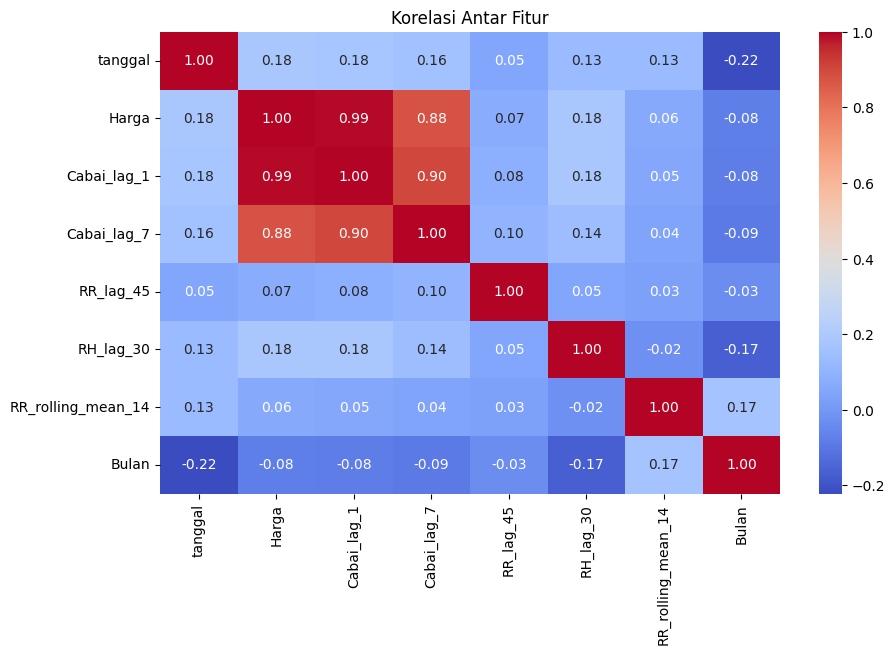

In [31]:
# Korelasi antar fitur
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur')
plt.show()

## export dataset

In [32]:
output_path = '../dataset/dataset_featured.csv'
df_features.to_csv(output_path, index=False)
print(f"\nDataset berhasil disimpan ke {output_path}")


Dataset berhasil disimpan ke ../dataset/dataset_featured.csv
